# Kv2.1 L403A: equal-depth sampling and early access to shifted S6 geometry

This analysis tests two distinct hypotheses using the established `all_ok_rmsd_3A_structural_interface_alignment_qc` subset:

1. Does targeted masking produce broader L403A S6 sampling at equal sampling depth?
2. Does targeted masking reach 8SDA-like S6 geometry earlier?

The earlier `SamplingDepth_AllOK3_vs_First100.ipynb` is preserved. This notebook focuses on L403A and evaluates cumulative retained-structure depths of 250, 500, 1,000, 2,000, and complete QC.

## Design and limitations

Structures are ordered deterministically by seed, model number, and recycle. No generation timestamps are available, so “early” means early in this reproducible index order, not proven wall-clock chronology. First-1,000 and full-QC sets contain correlated recycle snapshots; inference therefore resamples whole seeds and preserves every recycle/model/subunit belonging to a sampled seed.

Linear dispersion is the IQR. Angular dispersion is circular median absolute deviation. Positive log2(masked/vanilla dispersion) means broader masked sampling. Experimental relevance is analyzed separately using the lowest 5% of the pooled full-QC mean percentile error to 8SDA across kink angle, whole-S6 rotation, I401 azimuth, and I405 azimuth in remodeled subunits B/D. This threshold is descriptive and is not a new structural classifier.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image
repo_root=Path.cwd()
if not (repo_root/'shared').is_dir(): repo_root=repo_root.parent
sys.path.insert(0,str(repo_root))
from kv21.run_l403a_early_sampling_analysis import run, TAB, FIG
result=run()
print(json.dumps(result['summary'],indent=2))

findfont: Failed to find font weight semibold, now using 700.


{
  "bootstrap_replicates": 1000,
  "depths": [
    250,
    500,
    1000,
    2000,
    "Full QC"
  ],
  "primary_depth": 1000,
  "ordering": "seed/model/recycle; not timestamped chronology",
  "experimental_like_definition": "lowest 5% pooled full-QC mean percentile error across kink, S6 rotation, I401 and I405 azimuth in B/D"
}


## QC population and ordering audit

In [2]:
display(pd.read_csv(TAB/'l403a_sampling_depth_audit.csv'))

,protocol,qc_structures,seeds,min_seed,max_seed,order_definition
0,masked,3693,100,33.0,132.0,"seed, model_number, recycle; deterministic pro..."
1,vanilla,4371,100,55.0,154.0,"seed, model_number, recycle; deterministic pro..."


## Seed-clustered dispersion across cumulative sampling depths

,depth,canonical_subunit,metric,dispersion_definition,vanilla_dispersion,masked_dispersion,masked_vanilla_ratio,log2_ratio,log2_ratio_ci_low,log2_ratio_ci_high,masked_broader,bootstrap_p_two_sided,vanilla_structures,masked_structures,vanilla_seeds,masked_seeds,bootstrap_q_within_depth
0,250,A,kink_angle_deg,IQR (physical units),1.520469,1.955864,1.286356,0.363290,-0.295568,0.704625,True,0.301698,250,250,6,8,0.371321
1,250,A,whole_s6_rotation_vs_8SD3_deg,circular median absolute deviation (deg),0.593539,5.520397,9.300813,3.217357,1.806091,4.308736,True,0.001998,250,250,6,8,0.003996
2,250,A,I401_azimuth_deg,circular median absolute deviation (deg),0.767012,10.639785,13.871740,3.794077,2.774316,4.595831,True,0.001998,250,250,6,8,0.003996
3,250,A,I405_azimuth_deg,circular median absolute deviation (deg),1.856316,0.960792,0.517580,-0.950146,-1.488042,0.051609,False,0.067932,250,250,6,8,0.111888
4,250,B,kink_angle_deg,IQR (physical units),1.609036,1.943033,1.207576,0.272114,-0.412475,0.643272,True,0.449550,250,250,6,8,0.449550
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,Full QC,C,I405_azimuth_deg,circular median absolute deviation (deg),1.441089,0.928991,0.644645,-0.633423,-0.821915,-0.465619,False,0.001998,4371,3693,100,100,0.002459
76,Full QC,D,kink_angle_deg,IQR (physical units),1.560218,1.366787,0.876023,-0.190959,-0.305678,-0.087577,False,0.001998,4371,3693,100,100,0.002459
77,Full QC,D,whole_s6_rotation_vs_8SD3_deg,circular median absolute deviation (deg),0.577510,3.265734,5.654852,2.499489,2.314811,2.681794,True,0.001998,4371,3693,100,100,0.002459
78,Full QC,D,I401_azimuth_deg,circular median absolute deviation (deg),0.915813,6.328410,6.910156,2.788718,2.587484,3.007264,True,0.001998,4371,3693,100,100,0.002459


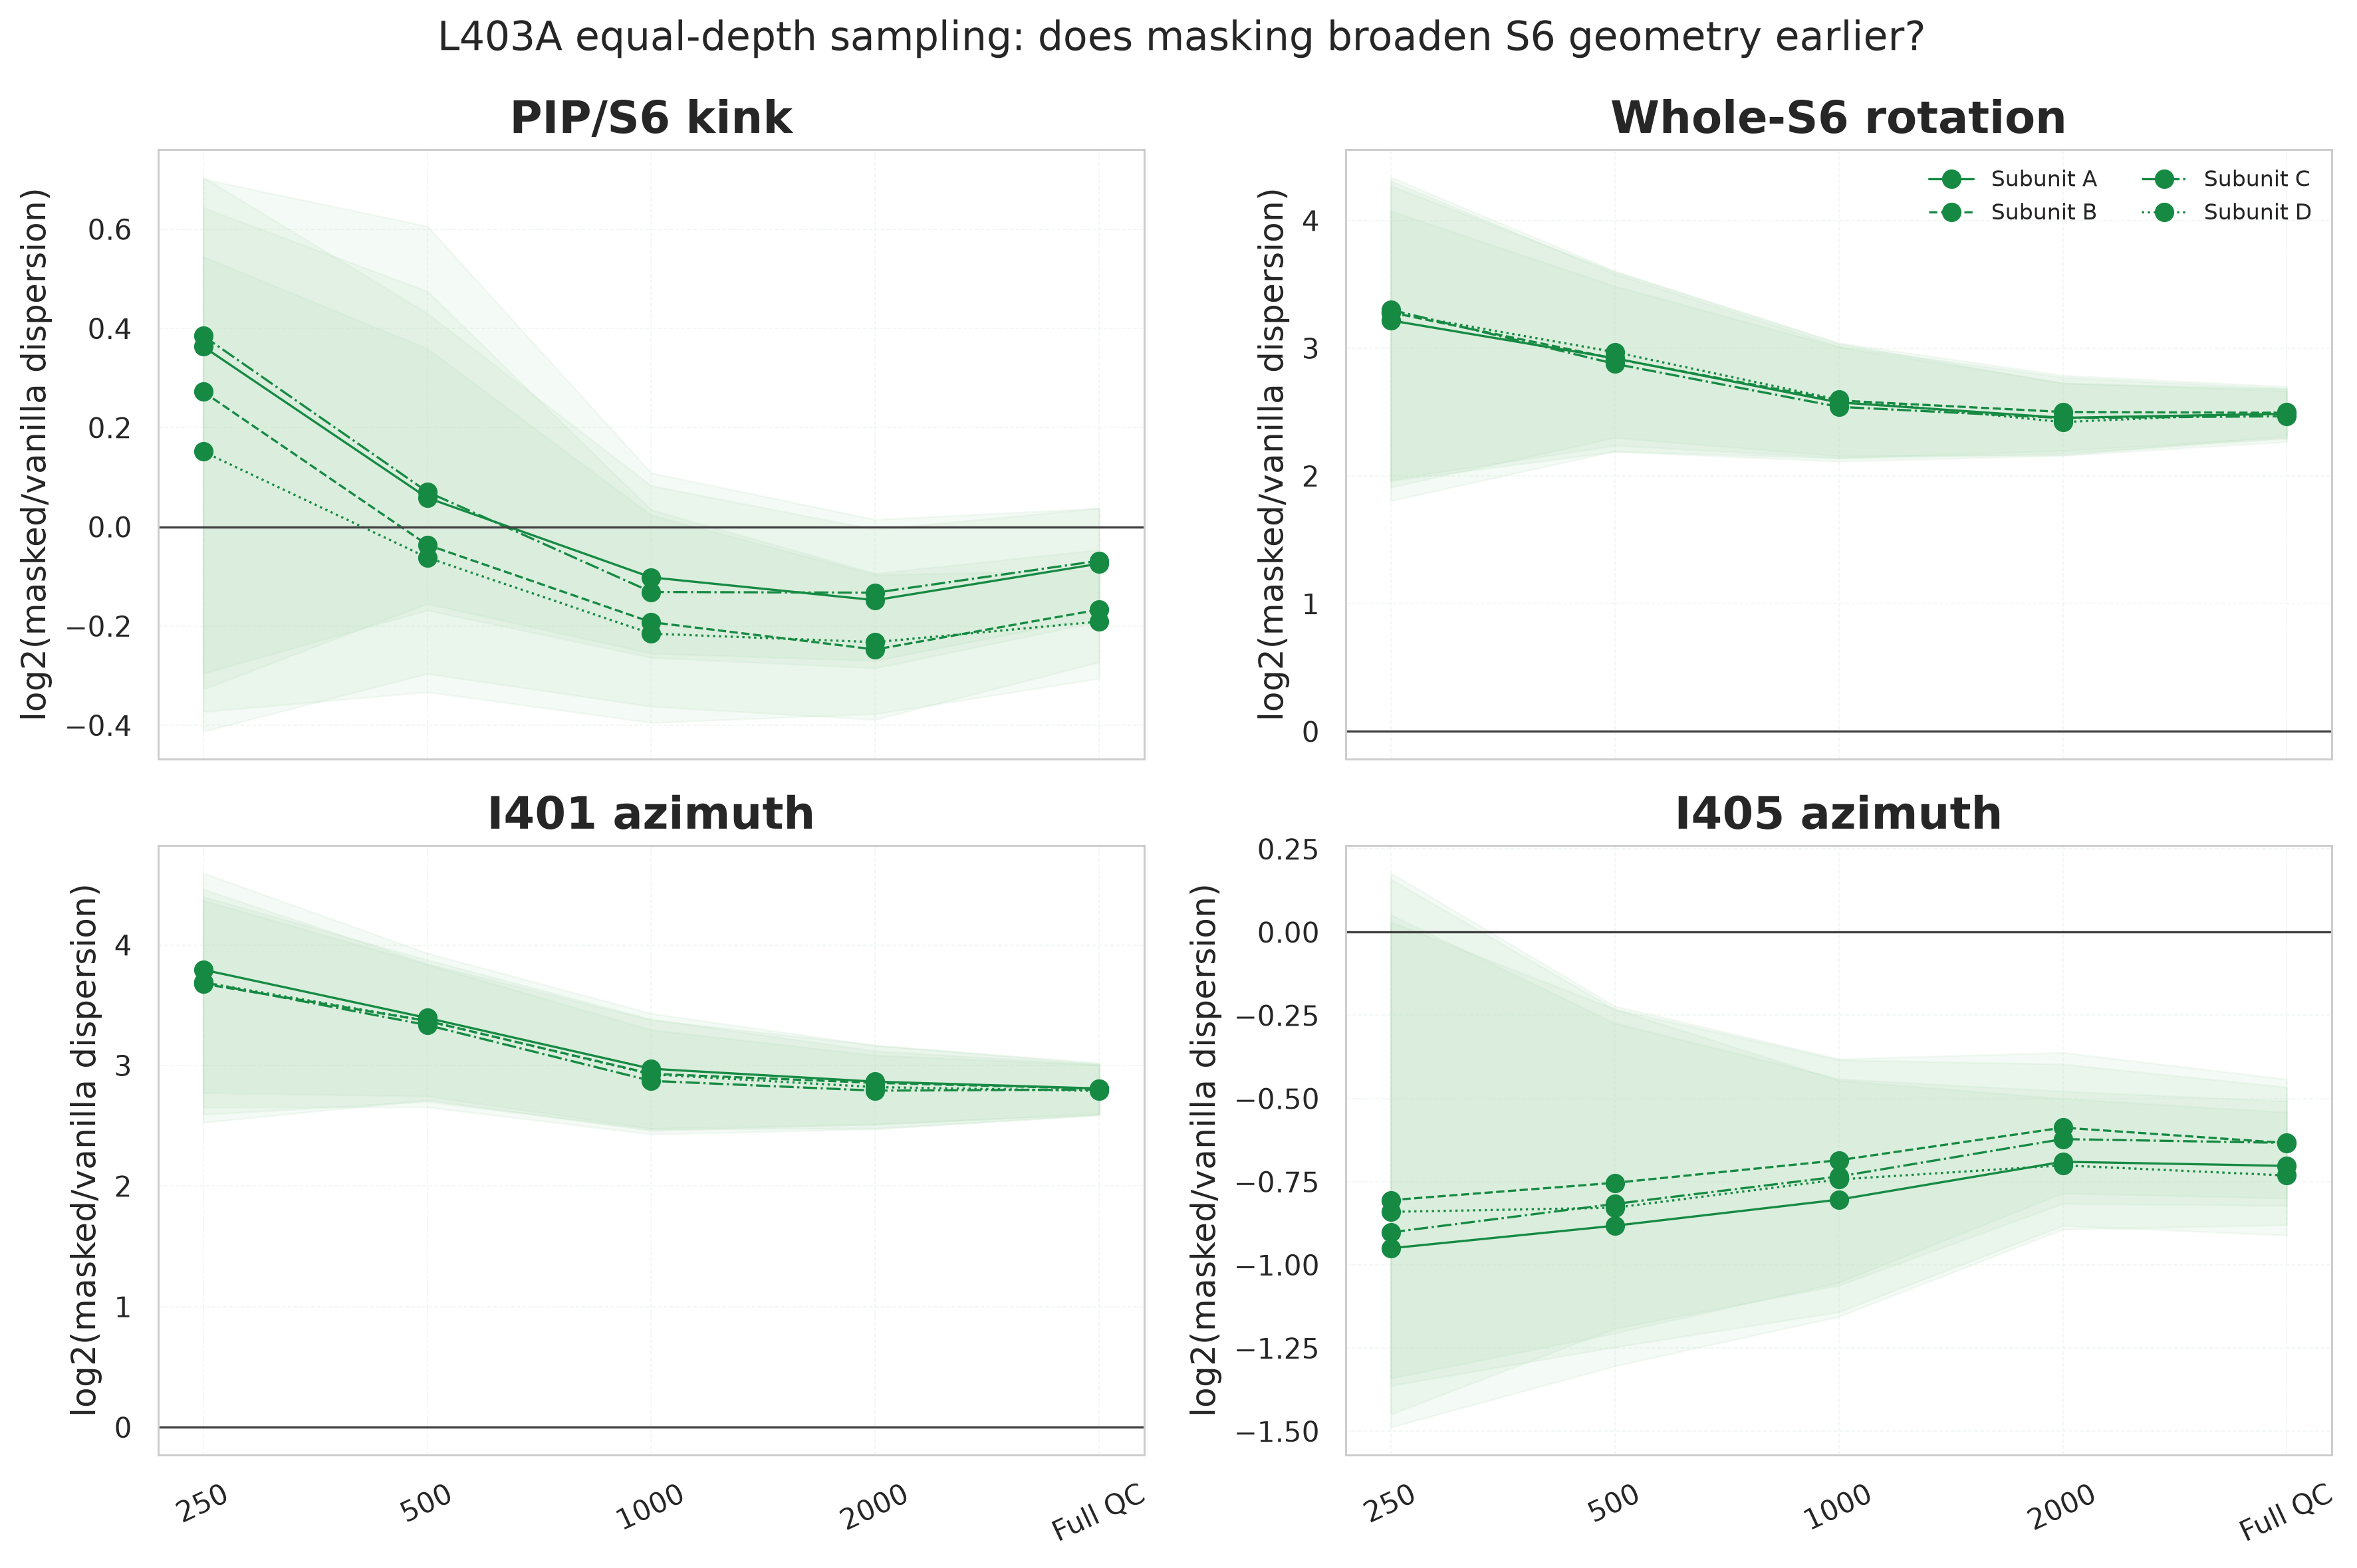

In [3]:
disp=pd.read_csv(TAB/'l403a_sampling_depth_dispersion.csv')
display(disp)
display(Image(filename=str(FIG/'l403a_sampling_depth_dispersion.png')))

## First 1,000 versus complete QC

In [4]:
display(disp[disp.depth.astype(str).isin(['1000','Full QC'])][['depth','canonical_subunit','metric','vanilla_dispersion','masked_dispersion','masked_vanilla_ratio','log2_ratio_ci_low','log2_ratio_ci_high','bootstrap_p_two_sided','bootstrap_q_within_depth','vanilla_seeds','masked_seeds']])

,depth,canonical_subunit,metric,vanilla_dispersion,masked_dispersion,masked_vanilla_ratio,log2_ratio_ci_low,log2_ratio_ci_high,bootstrap_p_two_sided,bootstrap_q_within_depth,vanilla_seeds,masked_seeds
32,1000,A,kink_angle_deg,1.649026,1.536523,0.931776,-0.263351,0.082842,0.237762,0.253613,23,28
33,1000,A,whole_s6_rotation_vs_8SD3_deg,0.554173,3.303702,5.961500,2.138085,3.015474,0.001998,0.002664,23,28
34,1000,A,I401_azimuth_deg,0.788850,6.192939,7.850594,2.478073,3.431272,0.001998,0.002664,23,28
35,1000,A,I405_azimuth_deg,1.441081,0.825400,0.572764,-1.155298,-0.441034,0.001998,0.002664,23,28
36,1000,B,kink_angle_deg,1.596306,1.397146,0.875237,-0.362175,0.034129,0.091908,0.105038,23,28
37,1000,B,whole_s6_rotation_vs_8SD3_deg,0.551269,3.320150,6.022745,2.141516,3.041024,0.001998,0.002664,23,28
38,1000,B,I401_azimuth_deg,0.814745,6.213187,7.625926,2.459797,3.377176,0.001998,0.002664,23,28
39,1000,B,I405_azimuth_deg,1.404191,0.873098,0.621780,-1.053058,-0.380959,0.001998,0.002664,23,28
40,1000,C,kink_angle_deg,1.515507,1.383634,0.912984,-0.255069,0.108623,0.357642,0.357642,23,28
41,1000,C,whole_s6_rotation_vs_8SD3_deg,0.562494,3.273626,5.819839,2.114060,3.007284,0.001998,0.002664,23,28


## Cumulative access to 8SDA-like B/D S6 geometry

,depth,vanilla_hit_fraction,masked_hit_fraction,hit_fraction_difference,difference_ci_low,difference_ci_high,vanilla_best_score,masked_best_score,vanilla_hits,masked_hits,vanilla_seeds,masked_seeds
0,250,0.044000,0.060000,0.016000,-0.066623,0.094166,0.115265,0.013703,11,15,6,8
1,500,0.050000,0.054000,0.004000,-0.045098,0.056088,0.073893,0.013703,25,27,12,14
2,1000,0.061000,0.042000,-0.019000,-0.054562,0.014561,0.060996,0.013703,61,42,23,28
3,2000,0.049500,0.038000,-0.011500,-0.034175,0.008593,0.055323,0.006402,99,76,46,56
4,Full QC,0.060856,0.037368,-0.023488,-0.039990,-0.007593,0.041264,0.006402,266,138,100,100


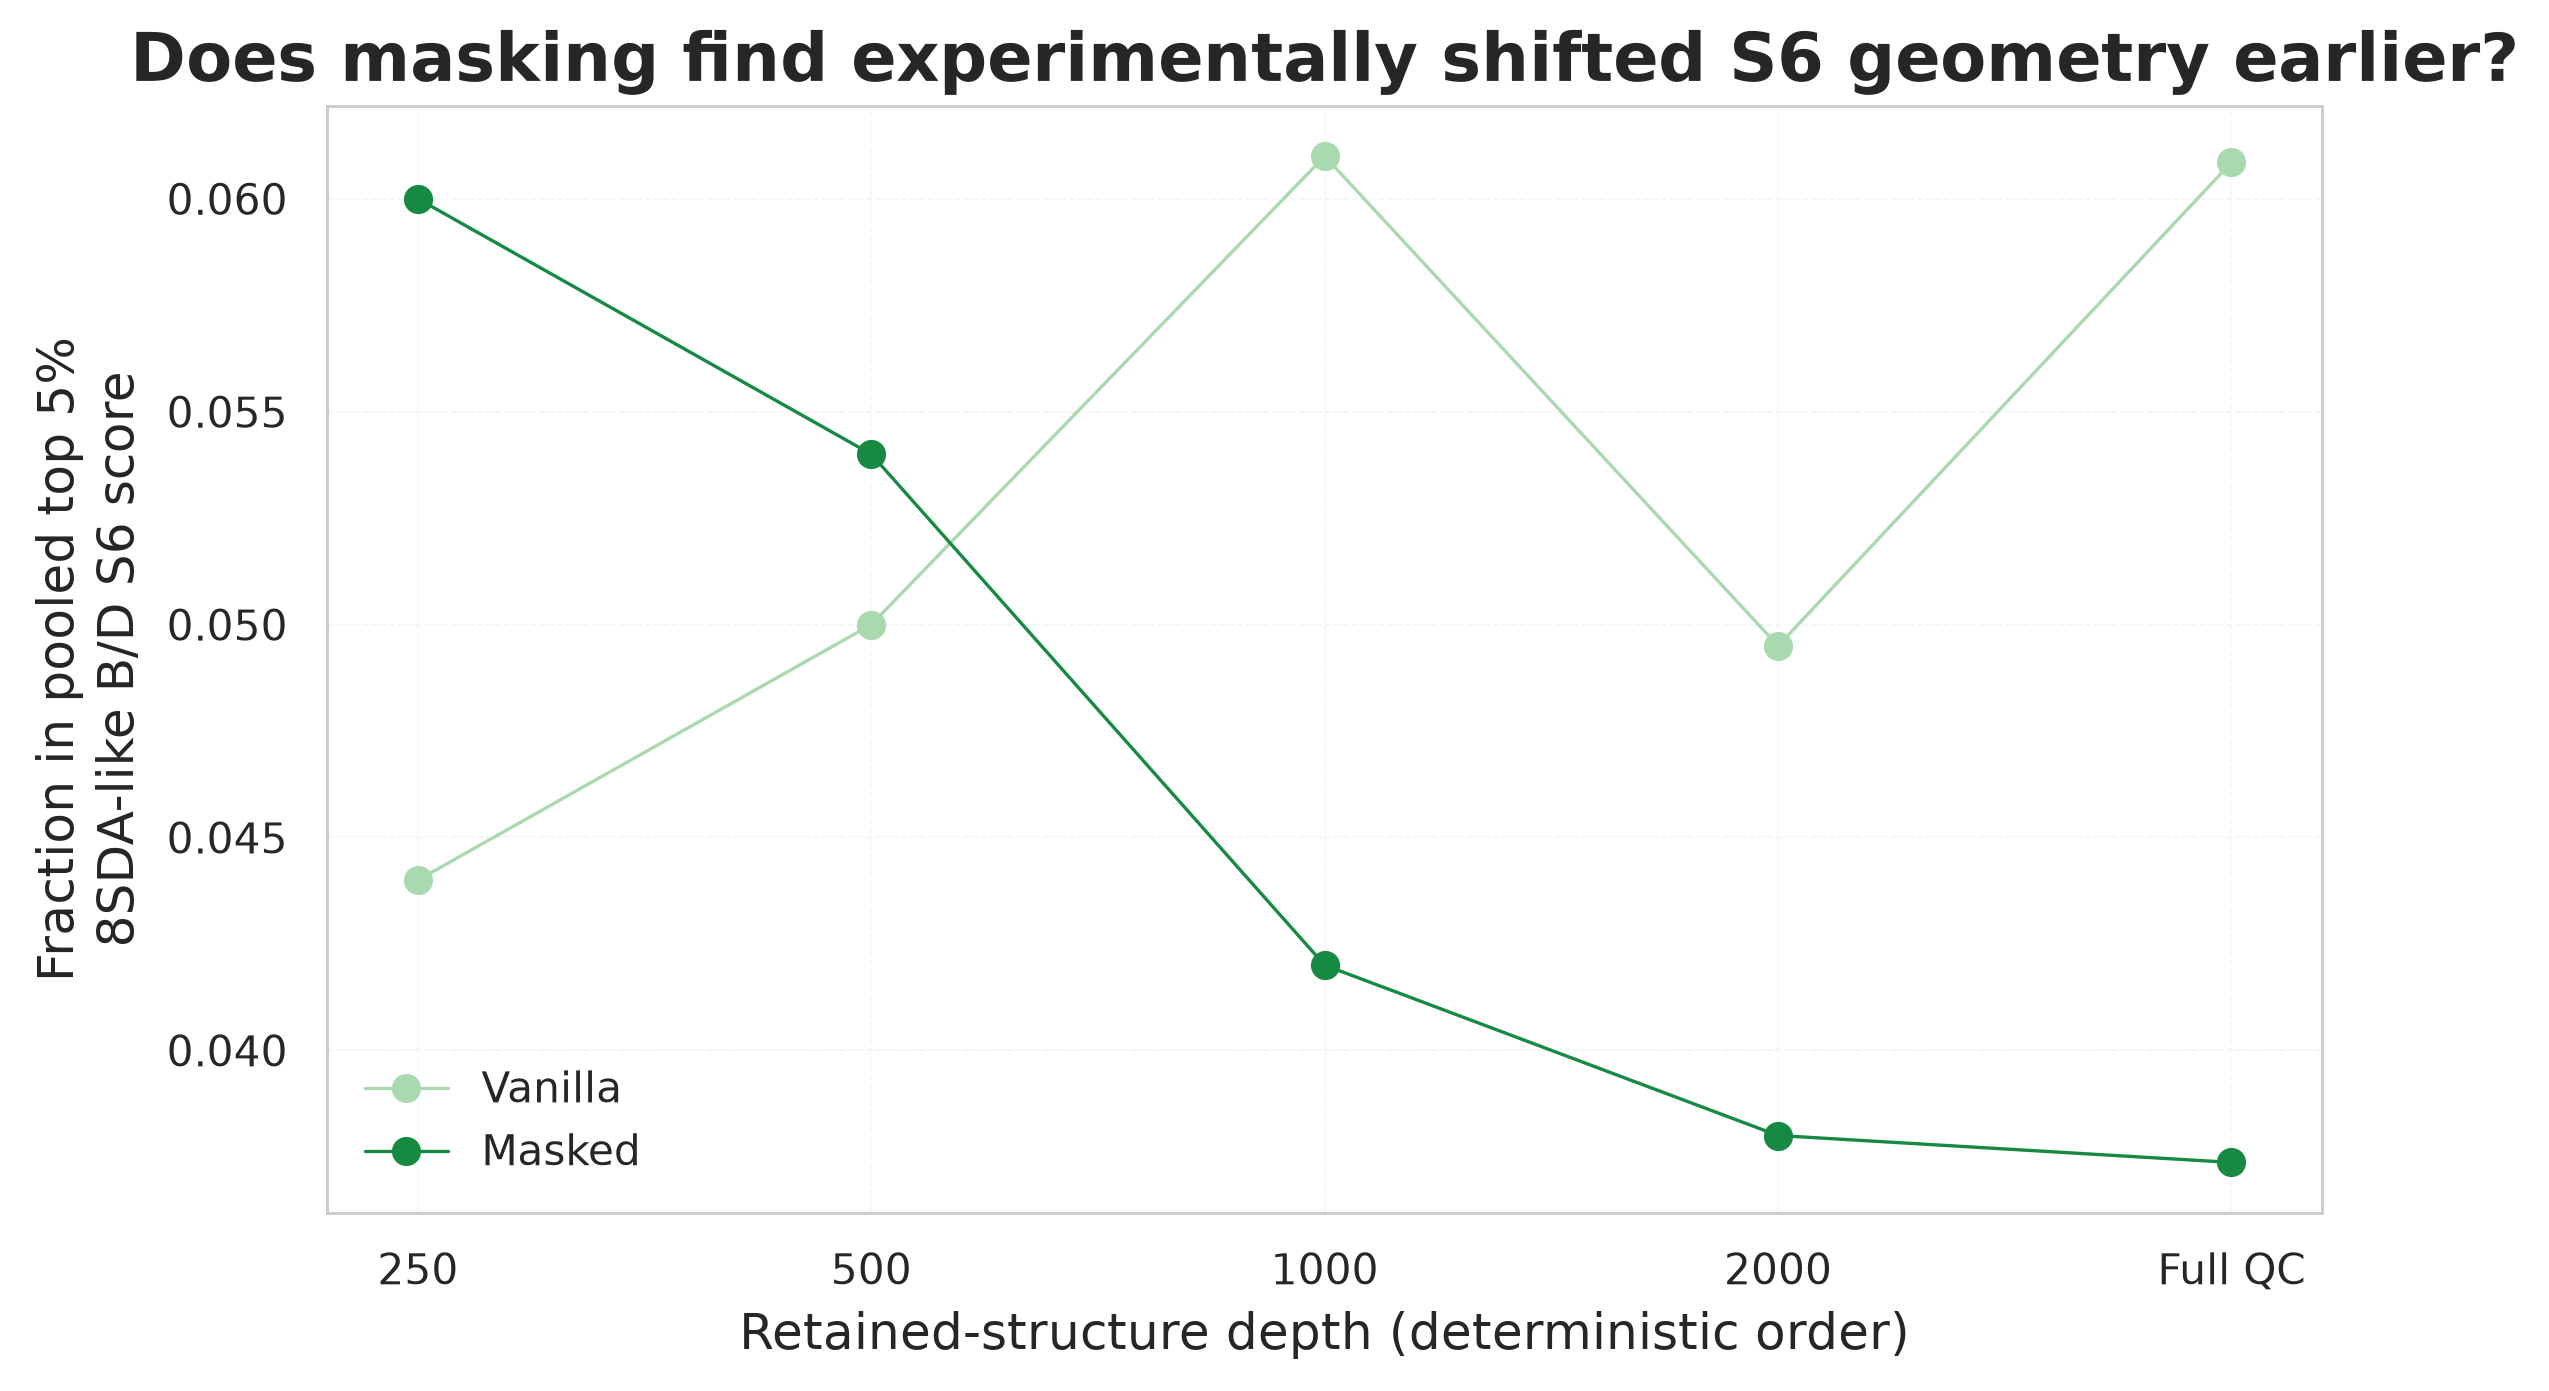

In [5]:
enrich=pd.read_csv(TAB/'l403a_sampling_depth_experimental_like_enrichment.csv')
display(enrich)
display(Image(filename=str(FIG/'l403a_sampling_depth_experimental_like_enrichment.png')))

## Statistical reading guide

- A dispersion-ratio confidence interval entirely above zero supports broader masked sampling for that specific metric and subunit.
- A hit-fraction-difference interval entirely above zero supports enrichment of 8SDA-like states under masking at that depth.
- A lower best score means the protocol has reached a more extreme 8SDA-like individual structure, which is different from increasing the population frequency of such structures.
- The first-1,000 comparison is valuable only alongside the cumulative curve and full-QC result; by itself it cannot distinguish a stable sampling effect from an arbitrary ordering fluctuation.